# PA1 — Segmentação de instâncias

Implementação gradual do trabalho de Aprendizado Profundo. Nesta primeira etapa, construiremos o teste unitário sintético exigido na Parte 0 do enunciado.

## Parte 0 — Dataset sintético

Cada imagem terá tamanho $128 \times 128$, entre 5 e 20 elipses, objetos frequentemente encostados e variações de ruído e contraste. O alvo é um mapa de instâncias: `0` representa o fundo e cada inteiro positivo identifica uma elipse diferente.

In [ ]:
print("hellho world")

hellho world


In [2]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
IMAGE_SIZE = 128
MIN_INSTANCES = 5
MAX_INSTANCES = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo selecionado: {device}")

if device.type == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name}")
    print(f"Memória total: {gpu.total_memory / 1024**3:.2f} GB")
    print(f"Compute capability: {gpu.major}.{gpu.minor}")

Dispositivo selecionado: cuda
GPU: Tesla T4
Memória total: 14.56 GB
Compute capability: 7.5


### Gerador de uma amostra

A função abaixo cria a imagem e seu mapa de instâncias simultaneamente. Parte das novas elipses é posicionada perto de uma elipse anterior para aumentar a frequência de objetos encostados. Uma posição só é aceita quando a elipse inteira cabe na imagem e não se sobrepõe a outra instância; portanto, cada forma permanece completa.

In [ ]:
def ellipse_mask(height, width, center_y, center_x, radius_y, radius_x, angle):
    """Retorna uma máscara booleana para uma elipse rotacionada."""
    y, x = np.ogrid[:height, :width]
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    x_centered = x - center_x
    y_centered = y - center_y
    x_rot = x_centered * cos_a + y_centered * sin_a
    y_rot = -x_centered * sin_a + y_centered * cos_a
    return (x_rot / radius_x) ** 2 + (y_rot / radius_y) ** 2 <= 1


def dilate_one_pixel(mask):
    """Dilata uma máscara em um pixel usando vizinhança 8-conectada."""
    padded = np.pad(mask, 1, mode="constant")
    dilated = np.zeros_like(mask)
    for dy in range(3):
        for dx in range(3):
            dilated |= padded[dy : dy + mask.shape[0], dx : dx + mask.shape[1]]
    return dilated


def generate_synthetic_sample(rng, image_size=128, min_instances=5, max_instances=20):
    """Gera uma imagem em tons de cinza e um mapa de rótulos de instância."""
    height = width = image_size
    labels = np.zeros((height, width), dtype=np.int32)
    centers = []
    radii = []
    target_instances = int(rng.integers(min_instances, max_instances + 1))

    for instance_id in range(1, target_instances + 1):
        placed = False
        contact_requested = bool(centers and rng.random() < 0.70)

        for attempt in range(1_000):
            # Depois de 400 tentativas, usamos formas menores e priorizamos espaço livre.
            if attempt < 400:
                radius_y = int(rng.integers(5, 14))
                radius_x = int(rng.integers(5, 14))
            else:
                radius_y = int(rng.integers(4, 8))
                radius_x = int(rng.integers(4, 8))
            angle = float(rng.uniform(0, np.pi))
            try_contact = contact_requested and attempt < 400
            # Extensão do retângulo que contém a elipse após a rotação.
            extent_y = int(np.ceil(np.sqrt(
                (radius_x * np.sin(angle)) ** 2 + (radius_y * np.cos(angle)) ** 2
            )))
            extent_x = int(np.ceil(np.sqrt(
                (radius_x * np.cos(angle)) ** 2 + (radius_y * np.sin(angle)) ** 2
            )))

            if try_contact:
                neighbor_idx = int(rng.integers(len(centers)))
                neighbor_y, neighbor_x = centers[neighbor_idx]
                neighbor_ry, neighbor_rx = radii[neighbor_idx]
                direction = float(rng.uniform(0, 2 * np.pi))
                min_distance = min(neighbor_ry, neighbor_rx) + min(radius_y, radius_x)
                max_distance = max(neighbor_ry, neighbor_rx) + max(radius_y, radius_x) + 2
                distance = float(rng.uniform(min_distance, max_distance))
                center_y = int(round(neighbor_y + np.sin(direction) * distance))
                center_x = int(round(neighbor_x + np.cos(direction) * distance))
            else:
                center_y = int(rng.integers(extent_y, height - extent_y))
                center_x = int(rng.integers(extent_x, width - extent_x))

            if not (extent_y <= center_y < height - extent_y):
                continue
            if not (extent_x <= center_x < width - extent_x):
                continue

            candidate = ellipse_mask(
                height, width, center_y, center_x, radius_y, radius_x, angle
            )
            occupied = labels > 0
            overlaps = np.any(candidate & occupied)
            touches = not try_contact or np.any(dilate_one_pixel(candidate) & occupied)

            if overlaps or not touches:
                continue

            labels[candidate] = instance_id
            centers.append((center_y, center_x))
            radii.append((radius_y, radius_x))
            placed = True
            break

        if not placed:
            raise RuntimeError(
                f"Falha ao posicionar a instância {instance_id} de {target_instances}."
            )

    background = float(rng.uniform(0.05, 0.25))
    contrast = float(rng.uniform(0.45, 0.85))
    image = np.full((height, width), background, dtype=np.float32)
    for instance_id in np.unique(labels)[1:]:
        intensity = np.clip(background + contrast + rng.normal(0, 0.08), 0, 1)
        image[labels == instance_id] = intensity

    noise_std = float(rng.uniform(0.02, 0.12))
    image += rng.normal(0, noise_std, image.shape).astype(np.float32)
    image = np.clip(image, 0, 1)
    return image, labels

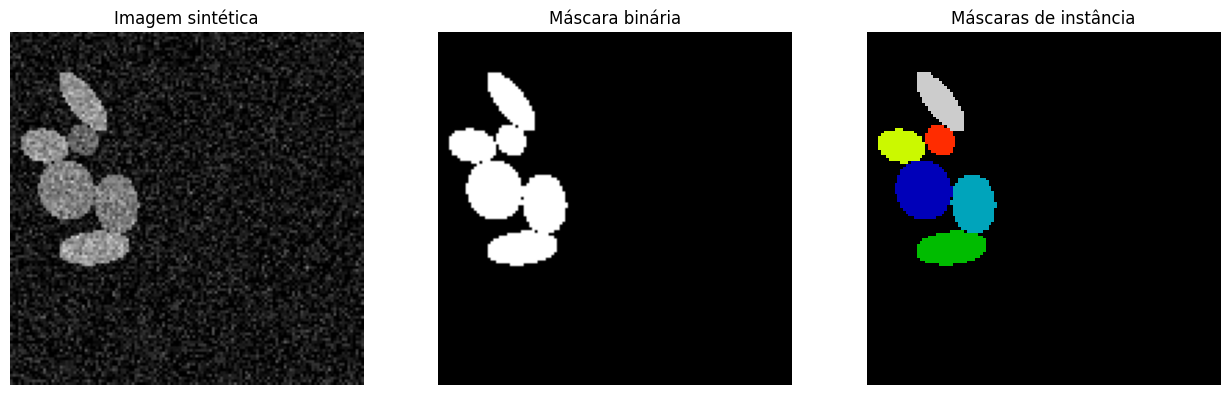

In [5]:
rng = np.random.default_rng(SEED)
sample_image, sample_labels = generate_synthetic_sample(rng, IMAGE_SIZE, MIN_INSTANCES, MAX_INSTANCES)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(sample_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Imagem sintética")
axes[1].imshow(sample_labels > 0, cmap="gray")
axes[1].set_title("Máscara binária")
axes[2].imshow(sample_labels, cmap="nipy_spectral", interpolation="nearest")
axes[2].set_title("Máscaras de instância")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
instance_ids = np.unique(sample_labels)[1:]

assert sample_image.shape == (IMAGE_SIZE, IMAGE_SIZE)
assert sample_labels.shape == (IMAGE_SIZE, IMAGE_SIZE)
assert sample_image.dtype == np.float32
assert sample_labels.dtype == np.int32
assert np.isfinite(sample_image).all()
assert 0 <= sample_image.min() <= sample_image.max() <= 1
assert np.array_equal(instance_ids, np.arange(1, len(instance_ids) + 1))
assert MIN_INSTANCES <= len(instance_ids) <= MAX_INSTANCES

print(f"Instâncias geradas: {len(instance_ids)}")
print(f"Intervalo de intensidade: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
print("Validações básicas concluídas com sucesso.")

Instâncias geradas: 6
Intervalo de intensidade: [0.000, 0.909]
Validações básicas concluídas com sucesso.


### Dataset e DataLoaders

A classe abaixo adapta o gerador à interface do PyTorch. Cada índice usa uma seed própria, o que torna as amostras reproduzíveis. Ela devolve a imagem, a máscara binária usada no treinamento da baseline, a máscara de instâncias usada na avaliação e a quantidade de objetos.

In [ ]:
from torch.utils.data import DataLoader, Dataset


class SyntheticEllipsesDataset(Dataset):
    def __init__(
        self,
        num_samples,
        base_seed,
        image_size=128,
        min_instances=5,
        max_instances=20,
    ):
        self.num_samples = num_samples
        self.base_seed = base_seed
        self.image_size = image_size
        self.min_instances = min_instances
        self.max_instances = max_instances
        self._cache = {}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        if index not in self._cache:
            rng = np.random.default_rng(self.base_seed + index)
            image, instance_mask = generate_synthetic_sample(
                rng=rng,
                image_size=self.image_size,
                min_instances=self.min_instances,
                max_instances=self.max_instances,
            )
            binary_mask = (instance_mask > 0).astype(np.float32)
            self._cache[index] = {
                "image": torch.from_numpy(image).unsqueeze(0),
                "binary_mask": torch.from_numpy(binary_mask).unsqueeze(0),
                "instance_mask": torch.from_numpy(instance_mask.astype(np.int64)),
                "num_instances": int(instance_mask.max()),
            }

        return self._cache[index]

In [ ]:
TRAIN_SAMPLES = 800
VAL_SAMPLES = 160
TEST_SAMPLES = 160
BATCH_SIZE = 32

train_dataset = SyntheticEllipsesDataset(TRAIN_SAMPLES, base_seed=SEED)
val_dataset = SyntheticEllipsesDataset(VAL_SAMPLES, base_seed=SEED + 10_000)
test_dataset = SyntheticEllipsesDataset(TEST_SAMPLES, base_seed=SEED + 20_000)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda",
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Treino: {len(train_dataset)} imagens / {len(train_loader)} batches")
print(f"Validação: {len(val_dataset)} imagens / {len(val_loader)} batches")
print(f"Teste: {len(test_dataset)} imagens / {len(test_loader)} batches")

Treino: 800 imagens / 25 batches
Validação: 160 imagens / 5 batches
Teste: 160 imagens / 5 batches


In [9]:
first_batch = next(iter(train_loader))

assert first_batch["image"].shape == (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["binary_mask"].shape == (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["instance_mask"].shape == (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["image"].dtype == torch.float32
assert first_batch["binary_mask"].dtype == torch.float32
assert first_batch["instance_mask"].dtype == torch.int64
assert torch.equal(train_dataset[0]["image"], train_dataset[0]["image"])

print("Formato das imagens:       ", tuple(first_batch["image"].shape))
print("Formato das máscaras:      ", tuple(first_batch["binary_mask"].shape))
print("Formato das instâncias:    ", tuple(first_batch["instance_mask"].shape))
print("Objetos por imagem no lote:", first_batch["num_instances"].tolist())
print("Dataset e DataLoaders validados com sucesso.")

Formato das imagens:        (32, 1, 128, 128)
Formato das máscaras:       (32, 1, 128, 128)
Formato das instâncias:     (32, 128, 128)
Objetos por imagem no lote: [9, 7, 15, 5, 13, 18, 9, 20, 15, 18, 6, 18, 17, 10, 19, 20, 5, 6, 12, 5, 8, 10, 16, 6, 18, 10, 8, 19, 8, 13, 5, 7]
Dataset e DataLoaders validados com sucesso.


## U-Net pequena — baseline binária

A rede recebe uma imagem em tons de cinza e produz um logit por pixel. O encoder reduz a resolução para aprender contexto; o decoder recupera a resolução; e as *skip connections* concatenam detalhes do encoder ao decoder. A ativação sigmoide não faz parte do modelo: ela será aplicada apenas ao converter logits em probabilidades.

In [10]:
import torch.nn as nn


class DoubleConv(nn.Module):
    """Duas convoluções 3x3, cada uma seguida por BatchNorm e ReLU."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c1, c2, c3, c4 = (
            base_channels,
            base_channels * 2,
            base_channels * 4,
            base_channels * 8,
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc1 = DoubleConv(in_channels, c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.bottleneck = DoubleConv(c3, c4)

        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c3 + c3, c3)
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c2 + c2, c2)
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c1 + c1, c1)
        self.head = nn.Conv2d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        skip1 = self.enc1(x)
        skip2 = self.enc2(self.pool(skip1))
        skip3 = self.enc3(self.pool(skip2))
        x = self.bottleneck(self.pool(skip3))

        x = self.up3(x)
        x = self.dec3(torch.cat([x, skip3], dim=1))
        x = self.up2(x)
        x = self.dec2(torch.cat([x, skip2], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, skip1], dim=1))
        return self.head(x)

In [12]:
model = SmallUNet().to(device)
test_images = first_batch["image"][:2].to(device)

model.eval()
with torch.inference_mode():
    test_logits = model(test_images)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
assert test_logits.shape == test_images.shape
assert test_logits.device == test_images.device
assert torch.isfinite(test_logits).all()

print(f"Entrada:    {tuple(test_images.shape)} em {test_images.device}")
print(f"Saída:      {tuple(test_logits.shape)} em {test_logits.device}")
print(f"Parâmetros: {num_parameters:,}")
print("Forward pass concluído com sucesso.")

Entrada:    (2, 1, 128, 128) em cuda:0
Saída:      (2, 1, 128, 128) em cuda:0
Parâmetros: 482,449
Forward pass concluído com sucesso.


### Perda e métricas semânticas

A baseline será otimizada com `BCEWithLogitsLoss`. Dice e IoU serão calculados após aplicar sigmoid e limiar de 0,5. Nesta etapa, essas métricas avaliam apenas foreground versus background; elas ainda não distinguem instâncias.

In [ ]:
criterion = nn.BCEWithLogitsLoss()


def binary_segmentation_metrics(logits, targets, threshold=0.5, epsilon=1e-7):
    """Calcula Dice e IoU médios por imagem a partir dos logits."""
    probabilities = torch.sigmoid(logits)
    predictions = probabilities >= threshold
    targets = targets >= 0.5

    reduce_dims = tuple(range(1, predictions.ndim))
    intersection = (predictions & targets).sum(dim=reduce_dims).float()
    predicted_area = predictions.sum(dim=reduce_dims).float()
    target_area = targets.sum(dim=reduce_dims).float()
    union = predicted_area + target_area - intersection

    dice = (2 * intersection + epsilon) / (predicted_area + target_area + epsilon)
    iou = (intersection + epsilon) / (union + epsilon)
    return {"dice": dice.mean().item(), "iou": iou.mean().item()}

In [14]:
test_targets = first_batch["binary_mask"][:2].to(device)
test_loss = criterion(test_logits, test_targets)
untrained_metrics = binary_segmentation_metrics(test_logits, test_targets)

# Logits muito positivos no objeto e negativos no fundo simulam uma predição perfeita.
perfect_logits = torch.where(test_targets > 0.5, 20.0, -20.0)
perfect_metrics = binary_segmentation_metrics(perfect_logits, test_targets)

assert torch.isfinite(test_loss)
assert 0 <= untrained_metrics["dice"] <= 1
assert 0 <= untrained_metrics["iou"] <= 1
assert abs(perfect_metrics["dice"] - 1.0) < 1e-6
assert abs(perfect_metrics["iou"] - 1.0) < 1e-6

print(f"Loss antes do treino: {test_loss.item():.4f}")
print(
    f"Modelo não treinado — Dice: {untrained_metrics['dice']:.4f} | "
    f"IoU: {untrained_metrics['iou']:.4f}"
)
print(
    f"Teste perfeito       — Dice: {perfect_metrics['dice']:.4f} | "
    f"IoU: {perfect_metrics['iou']:.4f}"
)
print("Perda e métricas validadas com sucesso.")

Loss antes do treino: 0.6340
Modelo não treinado — Dice: 0.0000 | IoU: 0.0000
Teste perfeito       — Dice: 1.0000 | IoU: 1.0000
Perda e métricas validadas com sucesso.


### Pré-validação dos splits sintéticos

Antes do treinamento, percorremos uma vez todas as seeds de treino, validação e teste. Isso confirma que o gerador consegue construir cada amostra e que todas contêm entre 5 e 20 instâncias. Como a geração é determinística por índice, as mesmas seeds serão usadas durante o treinamento.

In [15]:
for split_name, dataset in (
    ("treino", train_dataset),
    ("validação", val_dataset),
    ("teste", test_dataset),
):
    counts = [dataset[index]["num_instances"] for index in range(len(dataset))]
    assert min(counts) >= MIN_INSTANCES
    assert max(counts) <= MAX_INSTANCES
    print(
        f"{split_name.capitalize():10s}: {len(counts):4d} imagens | "
        f"instâncias entre {min(counts)} e {max(counts)}"
    )

print("Todos os splits sintéticos foram validados com sucesso.")

Treino    :  800 imagens | instâncias entre 5 e 20
Validação :  160 imagens | instâncias entre 5 e 20
Teste     :  160 imagens | instâncias entre 5 e 20
Todos os splits sintéticos foram validados com sucesso.


### Treinamento da baseline sintética

Treinaremos por 10 épocas com Adam. A cada época, a rede é avaliada sem gradientes no conjunto de validação. Guardamos em memória os pesos da época com menor loss de validação e medimos o tempo total para verificar o requisito de menos de cinco minutos.

In [16]:
import copy
import time


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.inference_mode()
def evaluate_semantic(model, loader, criterion, device):
    model.eval()
    totals = {"loss": 0.0, "dice": 0.0, "iou": 0.0}
    total_samples = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, targets)
        metrics = binary_segmentation_metrics(logits, targets)

        batch_size = images.shape[0]
        totals["loss"] += loss.item() * batch_size
        totals["dice"] += metrics["dice"] * batch_size
        totals["iou"] += metrics["iou"] * batch_size
        total_samples += batch_size

    return {name: value / total_samples for name, value in totals.items()}

In [17]:
EPOCHS = 10
LEARNING_RATE = 1e-3

# Reinicialização explícita para o experimento ser reproduzível.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = SmallUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_val_loss = float("inf")
best_state = None
best_epoch = 0

start_time = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate_semantic(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Época {epoch:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_metrics['loss']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f}"
    )

elapsed_seconds = time.perf_counter() - start_time
model.load_state_dict(best_state)

print(f"\nMelhor época: {best_epoch} (val loss = {best_val_loss:.4f})")
print(f"Tempo total: {elapsed_seconds:.1f} s ({elapsed_seconds / 60:.2f} min)")
if elapsed_seconds <= 300:
    print("Requisito de treinamento em menos de 5 minutos atendido.")
else:
    print("Atenção: o treinamento ultrapassou 5 minutos.")

Época 01/10 | train loss: 0.4350 | val loss: 0.4121 | Dice: 0.9225 | IoU: 0.8565
Época 02/10 | train loss: 0.3403 | val loss: 0.3211 | Dice: 0.9850 | IoU: 0.9705
Época 03/10 | train loss: 0.2855 | val loss: 0.2627 | Dice: 0.9960 | IoU: 0.9921
Época 04/10 | train loss: 0.2402 | val loss: 0.2193 | Dice: 0.9972 | IoU: 0.9945
Época 05/10 | train loss: 0.2019 | val loss: 0.1869 | Dice: 0.9989 | IoU: 0.9978
Época 06/10 | train loss: 0.1695 | val loss: 0.1576 | Dice: 0.9990 | IoU: 0.9980
Época 07/10 | train loss: 0.1425 | val loss: 0.1315 | Dice: 0.9992 | IoU: 0.9985
Época 08/10 | train loss: 0.1203 | val loss: 0.1125 | Dice: 0.9995 | IoU: 0.9989
Época 09/10 | train loss: 0.1020 | val loss: 0.0942 | Dice: 0.9993 | IoU: 0.9985
Época 10/10 | train loss: 0.0868 | val loss: 0.0792 | Dice: 0.9996 | IoU: 0.9991

Melhor época: 10 (val loss = 0.0792)
Tempo total: 18.5 s (0.31 min)
Requisito de treinamento em menos de 5 minutos atendido.


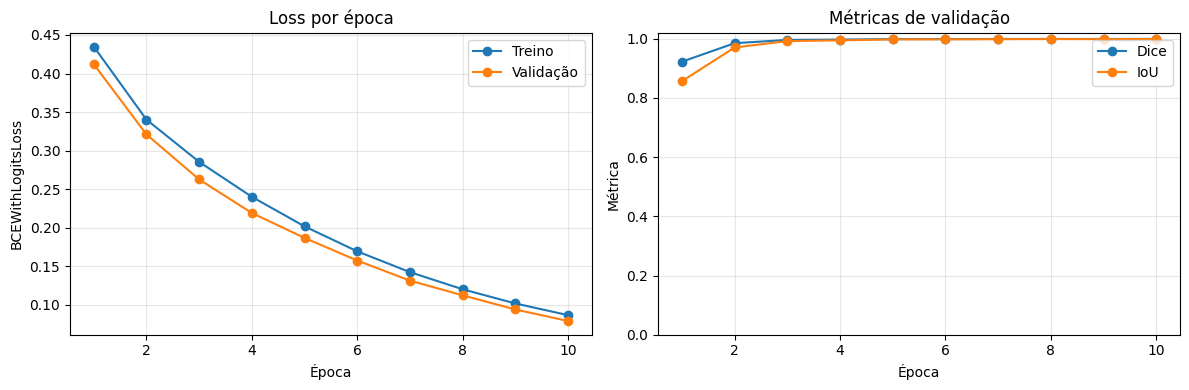

In [18]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Treino")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validação")
axes[0].set(title="Loss por época", xlabel="Época", ylabel="BCEWithLogitsLoss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["val_dice"], marker="o", label="Dice")
axes[1].plot(epochs, history["val_iou"], marker="o", label="IoU")
axes[1].set(title="Métricas de validação", xlabel="Época", ylabel="Métrica", ylim=(0, 1.02))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Avaliação semântica no conjunto de teste

Após selecionar os pesos pela menor loss de validação, avaliamos uma única vez no teste. Reportamos loss, Dice e IoU sem ajustar hiperparâmetros a partir desses resultados.

In [ ]:
test_metrics = evaluate_semantic(model, test_loader, criterion, device)

assert all(np.isfinite(value) for value in test_metrics.values())
assert 0 <= test_metrics["dice"] <= 1
assert 0 <= test_metrics["iou"] <= 1

print("Resultados semânticos no teste sintético")
print("─" * 42)
print(f"Loss:  {test_metrics['loss']:.4f}")
print(f"Dice:  {test_metrics['dice']:.4f}")
print(f"IoU:   {test_metrics['iou']:.4f}")

Resultados semânticos no teste sintético
──────────────────────────────────────────
Loss:  0.0788
Dice:  0.9995
IoU:   0.9991


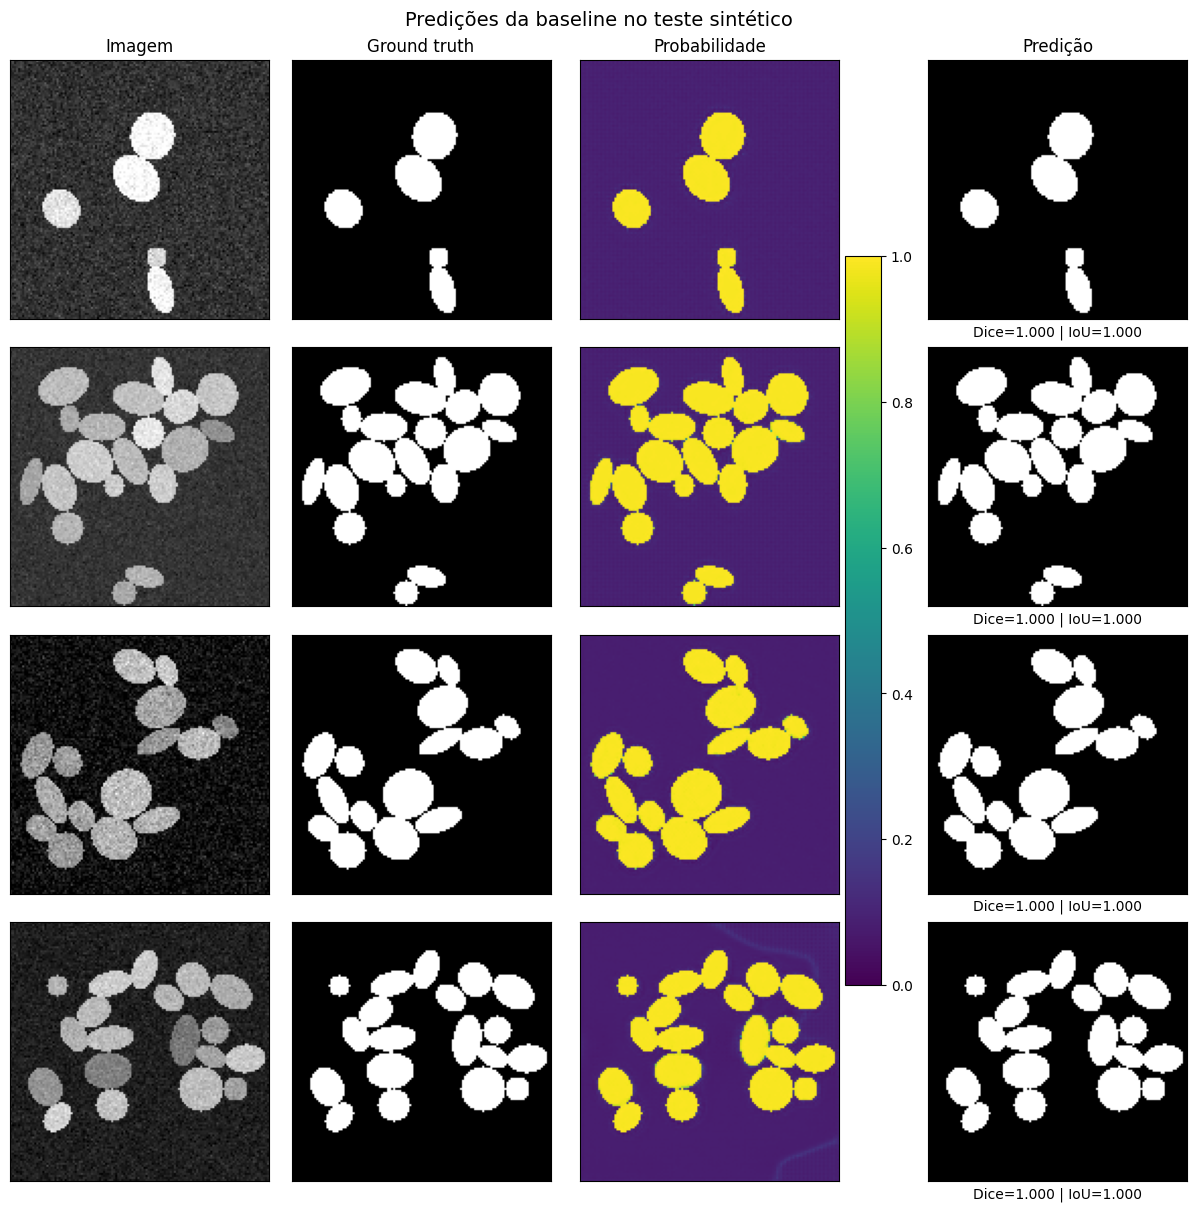

In [20]:
NUM_EXAMPLES = 4
example_batch = next(iter(test_loader))
example_images = example_batch["image"][:NUM_EXAMPLES].to(device)
example_targets = example_batch["binary_mask"][:NUM_EXAMPLES].to(device)

model.eval()
with torch.inference_mode():
    example_logits = model(example_images)
    example_probabilities = torch.sigmoid(example_logits)
    example_predictions = example_probabilities >= 0.5

images_np = example_images.cpu().numpy()
targets_np = example_targets.cpu().numpy()
probabilities_np = example_probabilities.cpu().numpy()
predictions_np = example_predictions.cpu().numpy()

fig, axes = plt.subplots(
    NUM_EXAMPLES, 4, figsize=(12, 3 * NUM_EXAMPLES), constrained_layout=True
)
column_titles = ["Imagem", "Ground truth", "Probabilidade", "Predição"]
for column, title in enumerate(column_titles):
    axes[0, column].set_title(title)

for row in range(NUM_EXAMPLES):
    sample_metrics = binary_segmentation_metrics(
        example_logits[row : row + 1], example_targets[row : row + 1]
    )
    axes[row, 0].imshow(images_np[row, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 1].imshow(targets_np[row, 0], cmap="gray", vmin=0, vmax=1)
    probability_plot = axes[row, 2].imshow(
        probabilities_np[row, 0], cmap="viridis", vmin=0, vmax=1
    )
    axes[row, 3].imshow(predictions_np[row, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 3].set_xlabel(
        f"Dice={sample_metrics['dice']:.3f} | IoU={sample_metrics['iou']:.3f}"
    )

for axis in axes.flat:
    axis.set_xticks([])
    axis.set_yticks([])
fig.colorbar(probability_plot, ax=axes[:, 2], shrink=0.65, pad=0.02)
fig.suptitle("Predições da baseline no teste sintético", fontsize=14)
plt.show()

# Parte 1 — Baseline de segmentação semântica

Usaremos o conjunto `stage1_train` do BBBC038v1/2018 Data Science Bowl. Cada amostra possui uma imagem PNG e uma máscara PNG separada para cada núcleo, sem sobreposição. A fonte oficial é o [Broad Bioimage Benchmark Collection](https://bbbc.broadinstitute.org/BBBC038), e o conjunto é disponibilizado sob CC0.

Nesta primeira etapa apenas baixaremos e inspecionaremos os dados. A estratégia de split será definida depois de examinarmos o metadata oficial.

In [21]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import BadZipFile, ZipFile

import pandas as pd
from PIL import Image

BBBC038_BASE_URL = "https://data.broadinstitute.org/bbbc/BBBC038"
DATA_ROOT = Path("data/BBBC038")
ARCHIVE_PATH = DATA_ROOT / "stage1_train.zip"
METADATA_PATH = DATA_ROOT / "metadata.xlsx"
TRAIN_ROOT = DATA_ROOT / "stage1_train"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

In [22]:
def is_valid_zip(path):
    if not path.exists():
        return False
    try:
        with ZipFile(path) as archive:
            return archive.testzip() is None
    except (BadZipFile, OSError):
        return False


def download_atomically(url, destination):
    partial_path = destination.with_suffix(destination.suffix + ".part")
    urlretrieve(url, partial_path)
    partial_path.replace(destination)


def find_sample_dirs(root):
    """Retorna somente pastas que possuem a estrutura images/ + masks/."""
    if not root.exists():
        return []
    return sorted(
        path
        for path in root.iterdir()
        if path.is_dir()
        and (path / "images").is_dir()
        and (path / "masks").is_dir()
    )


if not is_valid_zip(ARCHIVE_PATH):
    print("Baixando stage1_train.zip (aproximadamente 83 MB)...")
    download_atomically(
        f"{BBBC038_BASE_URL}/stage1_train.zip", ARCHIVE_PATH
    )
else:
    print("Arquivo stage1_train.zip íntegro já existe.")

if not is_valid_zip(METADATA_PATH):
    print("Baixando metadata.xlsx...")
    download_atomically(f"{BBBC038_BASE_URL}/metadata.xlsx", METADATA_PATH)
else:
    print("Arquivo metadata.xlsx íntegro já existe.")

# O ZIP oficial pode guardar os IDs diretamente ou dentro de stage1_train/.
# Procuramos as duas estruturas antes de tentar extrair novamente.
candidate_roots = [DATA_ROOT / "stage1_train", DATA_ROOT]
TRAIN_ROOT = max(candidate_roots, key=lambda root: len(find_sample_dirs(root)))
sample_dirs = find_sample_dirs(TRAIN_ROOT)

if len(sample_dirs) != 670:
    print(f"Extração incompleta ({len(sample_dirs)}/670). Extraindo...")
    with ZipFile(ARCHIVE_PATH) as archive:
        first_parts = {
            Path(name).parts[0]
            for name in archive.namelist()
            if Path(name).parts
        }
        archive_has_wrapper = first_parts == {"stage1_train"}
        extraction_root = DATA_ROOT if archive_has_wrapper else DATA_ROOT / "stage1_train"
        extraction_root.mkdir(parents=True, exist_ok=True)
        archive.extractall(extraction_root)

    TRAIN_ROOT = max(candidate_roots, key=lambda root: len(find_sample_dirs(root)))
    sample_dirs = find_sample_dirs(TRAIN_ROOT)
else:
    print("As 670 amostras já estão extraídas.")

assert len(sample_dirs) == 670, (
    f"Extração incompleta: encontramos {len(sample_dirs)}/670 amostras válidas."
)
print(f"670 amostras disponíveis em: {TRAIN_ROOT.resolve()}")

Baixando stage1_train.zip (aproximadamente 83 MB)...
Baixando metadata.xlsx...
Extração incompleta (0/670). Extraindo...
670 amostras disponíveis em: /content/data/BBBC038/stage1_train


In [23]:
sample_dirs = find_sample_dirs(TRAIN_ROOT)
assert len(sample_dirs) == 670, (
    f"Esperávamos 670 amostras, encontramos {len(sample_dirs)}."
)

first_sample_dir = sample_dirs[0]
image_paths = sorted((first_sample_dir / "images").glob("*.png"))
mask_paths = sorted((first_sample_dir / "masks").glob("*.png"))
assert len(image_paths) == 1
assert len(mask_paths) >= 1

with Image.open(image_paths[0]) as first_image:
    first_image_info = {
        "arquivo": image_paths[0].name,
        "modo": first_image.mode,
        "tamanho": first_image.size,
        "número de instâncias": len(mask_paths),
    }

metadata = pd.read_excel(METADATA_PATH)

print("Primeira amostra:")
for key, value in first_image_info.items():
    print(f"  {key}: {value}")

print()
print(f"Metadata: {metadata.shape[0]} linhas x {metadata.shape[1]} colunas")
display(metadata.head())

Primeira amostra:
  arquivo: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png
  modo: RGBA
  tamanho: (256, 256)
  número de instâncias: 27

Metadata: 43 linhas x 13 colunas


,id,project_id,image_set,image_group,cell_type,num_images,original_res,crop_size,SNR,contrast_ratio,total_nuclei,avg_obj_size,stain_type
0,1,bbbc002,training,Default,kc167-drosophila,72,512x512,256x256,1.615410,0.340140,2947,306.247659,Hoechst 33342
1,2,bbbc018,training,Default,ht29-human-colon-cancer,144,512x512,256x256,4.812093,0.092777,4408,126.136061,"Hoechst 33342, pH3, and phalloidin"
2,3,p_06Eggert,training,Default,human,49,1040x1392,520x696,2.415012,0.294603,4566,1059.452655,NaN
3,4,p_07mito,training,Default,human-iPS-derived-oligodendrocyte,5,520x694,260x347,1.689949,0.315849,408,142.241824,Hoechst
4,5,p_15jager,training,Default,human-brain-tissue,13,512x640,512x640,2.411154,0.167754,411,1243.527609,NaN


### Imagem, máscara binária e mapa de instâncias

Cada PNG em `masks/` corresponde a um único núcleo. A união dessas máscaras produz o *ground truth* binário usado pela baseline semântica. Para preservar a identidade dos objetos, também construímos um mapa inteiro: `0` representa o fundo e `1, 2, 3, ...` representam núcleos diferentes.

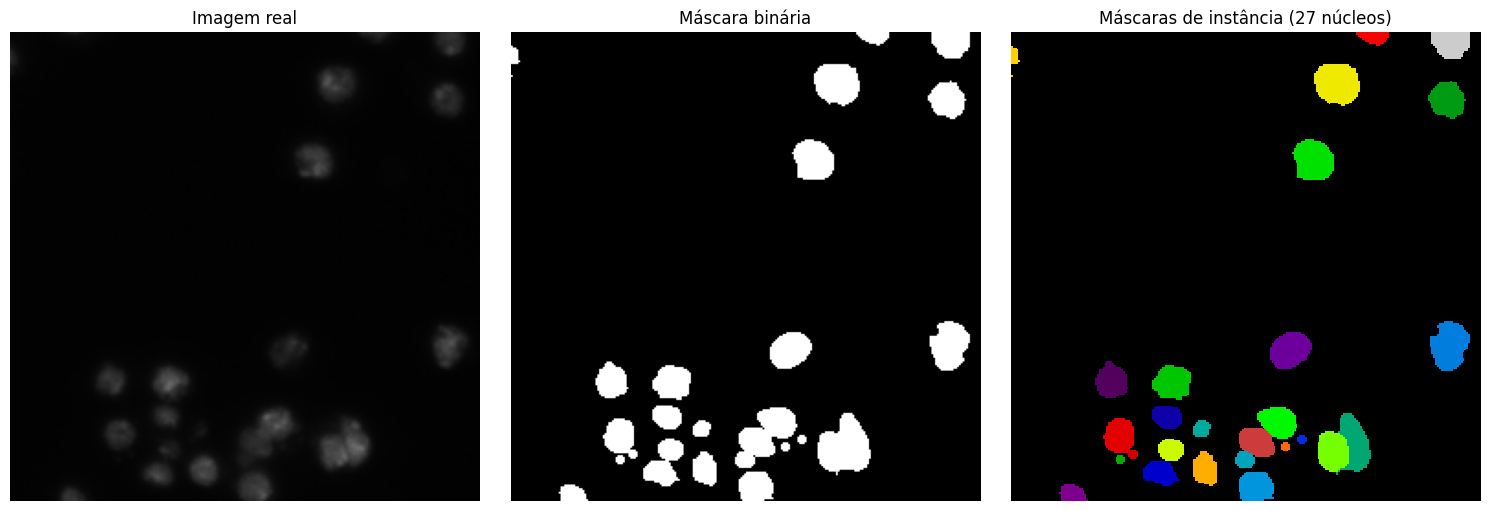

Imagem: (256, 256, 3) uint8
Máscara binária: (256, 256) bool
Mapa de instâncias: (256, 256) int32


In [24]:
def load_bbbc038_sample(sample_dir):
    image_path = next((sample_dir / "images").glob("*.png"))
    mask_paths = sorted((sample_dir / "masks").glob("*.png"))

    with Image.open(image_path) as image_file:
        image = np.asarray(image_file.convert("RGB"))

    instance_mask = np.zeros(image.shape[:2], dtype=np.int32)
    for instance_id, mask_path in enumerate(mask_paths, start=1):
        with Image.open(mask_path) as mask_file:
            object_mask = np.asarray(mask_file.convert("L")) > 0

        assert object_mask.shape == instance_mask.shape
        assert not np.any(object_mask & (instance_mask > 0)), (
            f"Máscaras sobrepostas em {sample_dir.name}."
        )
        instance_mask[object_mask] = instance_id

    binary_mask = instance_mask > 0
    return image, binary_mask, instance_mask


real_image, real_binary_mask, real_instance_mask = load_bbbc038_sample(
    first_sample_dir
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
axes[0].imshow(real_image)
axes[0].set_title("Imagem real")
axes[1].imshow(real_binary_mask, cmap="gray")
axes[1].set_title("Máscara binária")
axes[2].imshow(real_instance_mask, cmap="nipy_spectral", interpolation="nearest")
axes[2].set_title(f"Máscaras de instância ({real_instance_mask.max()} núcleos)")

for axis in axes:
    axis.axis("off")

plt.show()

print("Imagem:", real_image.shape, real_image.dtype)
print("Máscara binária:", real_binary_mask.shape, real_binary_mask.dtype)
print("Mapa de instâncias:", real_instance_mask.shape, real_instance_mask.dtype)

### Catálogo e distribuição de densidade

Criamos uma linha por imagem com suas dimensões, quantidade de instâncias e densidade de núcleos. A densidade é normalizada pela área da imagem (`núcleos por 100 mil pixels`), pois contar objetos sem considerar o tamanho da imagem produziria uma comparação injusta.

,width,height,num_instances,instances_per_100k_pixels
count,670.00,670.00,670.00,670.00
mean,378.50,333.99,43.97,37.97
std,204.84,149.47,47.96,31.83
min,256.00,256.00,1.00,0.97
25%,256.00,256.00,15.25,15.26
50%,320.00,256.00,27.00,25.59
75%,360.00,360.00,54.00,53.41
max,1388.00,1040.00,375.00,184.33


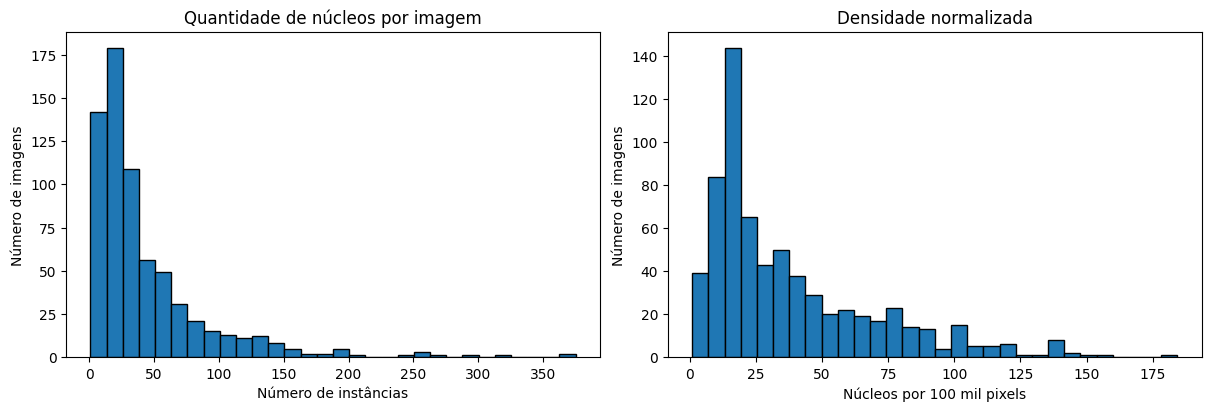

Modos de imagem:


,quantidade
mode,
RGBA,670


In [25]:
catalog_records = []

for sample_dir in sample_dirs:
    image_path = next((sample_dir / "images").glob("*.png"))
    num_instances = len(list((sample_dir / "masks").glob("*.png")))

    with Image.open(image_path) as image_file:
        width, height = image_file.size
        image_mode = image_file.mode

    area = width * height
    catalog_records.append(
        {
            "image_id": sample_dir.name,
            "width": width,
            "height": height,
            "mode": image_mode,
            "num_instances": num_instances,
            "instances_per_100k_pixels": num_instances / area * 100_000,
        }
    )

image_catalog = pd.DataFrame(catalog_records)
assert len(image_catalog) == 670
assert image_catalog["image_id"].is_unique

display(
    image_catalog[
        ["width", "height", "num_instances", "instances_per_100k_pixels"]
    ].describe().round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(image_catalog["num_instances"], bins=30, edgecolor="black")
axes[0].set_title("Quantidade de núcleos por imagem")
axes[0].set_xlabel("Número de instâncias")
axes[0].set_ylabel("Número de imagens")

axes[1].hist(
    image_catalog["instances_per_100k_pixels"], bins=30, edgecolor="black"
)
axes[1].set_title("Densidade normalizada")
axes[1].set_xlabel("Núcleos por 100 mil pixels")
axes[1].set_ylabel("Número de imagens")

plt.show()

print("Modos de imagem:")
display(image_catalog["mode"].value_counts().rename("quantidade").to_frame())

### Split estratificado: treino, validação e teste

Separamos 70%/15%/15% das imagens. Como o `metadata.xlsx` descreve grupos agregados e não associa cada `image_id` a um grupo, usamos como variável observável a densidade normalizada. Cinco faixas de densidade são representadas proporcionalmente nos três splits. A semente fixa torna a divisão reprodutível.

O conjunto de validação será usado para escolher configurações e o teste ficará reservado para a avaliação final.

In [26]:
from sklearn.model_selection import train_test_split


SPLIT_SEED = 42
split_catalog = image_catalog.copy()
density_labels = ["muito baixa", "baixa", "média", "alta", "muito alta"]

# O rank(method="first") resolve empates e mantém as cinco faixas balanceadas.
split_catalog["density_bin"] = pd.qcut(
    split_catalog["instances_per_100k_pixels"].rank(method="first"),
    q=5,
    labels=density_labels,
)

train_catalog, remaining_catalog = train_test_split(
    split_catalog,
    test_size=0.30,
    random_state=SPLIT_SEED,
    stratify=split_catalog["density_bin"],
)

val_catalog, test_catalog = train_test_split(
    remaining_catalog,
    test_size=0.50,
    random_state=SPLIT_SEED,
    stratify=remaining_catalog["density_bin"],
)

train_catalog = train_catalog.sort_values("image_id").reset_index(drop=True)
val_catalog = val_catalog.sort_values("image_id").reset_index(drop=True)
test_catalog = test_catalog.sort_values("image_id").reset_index(drop=True)

train_ids = set(train_catalog["image_id"])
val_ids = set(val_catalog["image_id"])
test_ids = set(test_catalog["image_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)
assert train_ids | val_ids | test_ids == set(image_catalog["image_id"])

split_sizes = pd.Series(
    {
        "treino": len(train_catalog),
        "validação": len(val_catalog),
        "teste": len(test_catalog),
    },
    name="número de imagens",
)
display(split_sizes.to_frame())

split_summary = pd.concat(
    [
        train_catalog.assign(split="treino"),
        val_catalog.assign(split="validação"),
        test_catalog.assign(split="teste"),
    ],
    ignore_index=True,
)

display(
    pd.crosstab(split_summary["density_bin"], split_summary["split"])
    .reindex(index=density_labels, columns=["treino", "validação", "teste"])
)

display(
    split_summary.groupby("split", observed=True)[
        ["num_instances", "instances_per_100k_pixels"]
    ].mean().round(2)
)

,número de imagens
treino,469
validação,100
teste,101


split,treino,validação,teste
density_bin,,,
muito baixa,93,20,21
baixa,94,20,20
média,94,20,20
alta,94,20,20
muito alta,94,20,20


,num_instances,instances_per_100k_pixels
split,,
teste,40.13,37.51
treino,43.17,38.16
validação,51.63,37.55


### Dataset do PyTorch para os dados reais

As imagens possuem resoluções diferentes. Durante o treino extraímos recortes aleatórios de `256 × 256`, que podem ser agrupados em lotes sem deformar os núcleos. Para validação e teste mantemos a imagem completa e usamos `batch_size=1`. A imagem é convertida para um canal em escala de cinza; a máscara binária é o alvo da baseline e o mapa inteiro de instâncias será usado posteriormente nas métricas por objeto.

In [27]:
class BBBC038Dataset(Dataset):
    def __init__(self, catalog, data_root, crop_size=None, augment=False):
        self.catalog = catalog.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.crop_size = crop_size
        self.augment = augment

    def __len__(self):
        return len(self.catalog)

    def _random_crop(self, image, binary_mask, instance_mask):
        crop_height, crop_width = self.crop_size
        height, width = image.shape

        # Padding torna a classe robusta caso apareça uma imagem menor que o crop.
        pad_height = max(0, crop_height - height)
        pad_width = max(0, crop_width - width)
        if pad_height or pad_width:
            padding = ((0, pad_height), (0, pad_width))
            image = np.pad(image, padding, mode="constant")
            binary_mask = np.pad(binary_mask, padding, mode="constant")
            instance_mask = np.pad(instance_mask, padding, mode="constant")
            height, width = image.shape

        top = np.random.randint(0, height - crop_height + 1)
        left = np.random.randint(0, width - crop_width + 1)
        rows = slice(top, top + crop_height)
        columns = slice(left, left + crop_width)
        return image[rows, columns], binary_mask[rows, columns], instance_mask[rows, columns]

    def __getitem__(self, index):
        image_id = self.catalog.iloc[index]["image_id"]
        sample_dir = self.data_root / image_id
        rgb_image, binary_mask, instance_mask = load_bbbc038_sample(sample_dir)

        # A SmallUNet sintética recebe um canal; mantemos essa interface.
        image = np.asarray(Image.fromarray(rgb_image).convert("L"), dtype=np.float32)
        image /= 255.0

        if self.crop_size is not None:
            image, binary_mask, instance_mask = self._random_crop(
                image, binary_mask, instance_mask
            )

        if self.augment:
            if np.random.random() < 0.5:
                image = np.flip(image, axis=1)
                binary_mask = np.flip(binary_mask, axis=1)
                instance_mask = np.flip(instance_mask, axis=1)
            if np.random.random() < 0.5:
                image = np.flip(image, axis=0)
                binary_mask = np.flip(binary_mask, axis=0)
                instance_mask = np.flip(instance_mask, axis=0)

        # copy() remove strides negativos criados por np.flip.
        image_tensor = torch.from_numpy(image.copy()).unsqueeze(0).float()
        binary_tensor = torch.from_numpy(binary_mask.copy()).unsqueeze(0).float()
        instance_tensor = torch.from_numpy(instance_mask.copy()).long()

        return {
            "image": image_tensor,
            "binary_mask": binary_tensor,
            "instance_mask": instance_tensor,
            "image_id": image_id,
        }


TRAIN_CROP_SIZE = (256, 256)
REAL_BATCH_SIZE = 8

real_train_dataset = BBBC038Dataset(
    train_catalog, TRAIN_ROOT, crop_size=TRAIN_CROP_SIZE, augment=True
)
real_val_dataset = BBBC038Dataset(val_catalog, TRAIN_ROOT)
real_test_dataset = BBBC038Dataset(test_catalog, TRAIN_ROOT)

loader_generator = torch.Generator().manual_seed(SPLIT_SEED)
real_train_loader = DataLoader(
    real_train_dataset,
    batch_size=REAL_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
real_val_loader = DataLoader(
    real_val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
real_test_loader = DataLoader(
    real_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

sample_batch = next(iter(real_train_loader))
print("Imagem do lote:", tuple(sample_batch["image"].shape))
print("Máscara binária:", tuple(sample_batch["binary_mask"].shape))
print("Mapa de instâncias:", tuple(sample_batch["instance_mask"].shape))
print("Intervalo da imagem:", sample_batch["image"].min().item(), "a", sample_batch["image"].max().item())

Imagem do lote: (8, 1, 256, 256)
Máscara binária: (8, 1, 256, 256)
Mapa de instâncias: (8, 256, 256)
Intervalo da imagem: 0.007843137718737125 a 1.0


### Padding para inferência em resolução completa

A U-Net reduz a resolução três vezes por um fator 2; por isso, altura e largura precisam ser divisíveis por `2³ = 8`. A função abaixo completa apenas a borda direita e inferior até o próximo múltiplo de 8, executa o modelo e remove o acréscimo da predição. O conteúdo original e as métricas permanecem com a resolução real.

In [28]:
def forward_with_padding(model, images, multiple=8):
    original_height, original_width = images.shape[-2:]
    height_remainder = original_height % multiple
    width_remainder = original_width % multiple

    if height_remainder == 0:
        pad_height = 0
    else:
        pad_height = multiple - height_remainder

    if width_remainder == 0:
        pad_width = 0
    else:
        pad_width = multiple - width_remainder

    padded_images = torch.nn.functional.pad(
        images,
        pad=(0, pad_width, 0, pad_height),
        mode="reflect",
    )
    padded_logits = model(padded_images)
    logits = padded_logits[..., :original_height, :original_width]
    return logits


height_is_irregular = val_catalog["height"] % 8 != 0
width_is_irregular = val_catalog["width"] % 8 != 0
irregular_rows = height_is_irregular | width_is_irregular
irregular_indices = val_catalog.index[irregular_rows].tolist()
assert irregular_indices, "Não foi encontrada imagem para testar o padding."

irregular_sample = real_val_dataset[irregular_indices[0]]
irregular_image = irregular_sample["image"].unsqueeze(0).to(device)
shape_check_model = SmallUNet().to(device).eval()

with torch.inference_mode():
    irregular_logits = forward_with_padding(shape_check_model, irregular_image)

assert irregular_logits.shape == irregular_image.shape
print("Entrada original:", tuple(irregular_image.shape))
print("Saída recortada:", tuple(irregular_logits.shape))
print("Teste de dimensões concluído sem erro.")

del shape_check_model, irregular_image, irregular_logits

Entrada original: (1, 1, 603, 1272)
Saída recortada: (1, 1, 603, 1272)
Teste de dimensões concluído sem erro.


### Configuração da baseline binária

A baseline usa uma nova `SmallUNet`, iniciada do zero, com uma saída por pixel. Mantemos `BCEWithLogitsLoss` para medir primeiro o desempenho da formulação binária mais simples. O Adam atualiza os pesos com taxa de aprendizado `0.001`.

In [29]:
REAL_LEARNING_RATE = 0.001

torch.manual_seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)

real_baseline_model = SmallUNet(
    in_channels=1,
    out_channels=1,
    base_channels=16,
).to(device)

real_baseline_criterion = nn.BCEWithLogitsLoss()
real_baseline_optimizer = torch.optim.Adam(
    real_baseline_model.parameters(),
    lr=REAL_LEARNING_RATE,
)


@torch.inference_mode()
def evaluate_real_semantic(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    number_of_images = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)

        logits = forward_with_padding(model, images)
        loss = criterion(logits, targets)
        metrics = binary_segmentation_metrics(logits, targets)

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_dice += metrics["dice"] * batch_size
        total_iou += metrics["iou"] * batch_size
        number_of_images += batch_size

    return {
        "loss": total_loss / number_of_images,
        "dice": total_dice / number_of_images,
        "iou": total_iou / number_of_images,
    }


number_of_parameters = sum(
    parameter.numel() for parameter in real_baseline_model.parameters()
)
print(f"Modelo criado no dispositivo: {device}")
print(f"Número de parâmetros: {number_of_parameters:,}")
print(f"Learning rate: {REAL_LEARNING_RATE}")

Modelo criado no dispositivo: cuda
Número de parâmetros: 482,449
Learning rate: 0.001


### Treinamento da baseline

Treinamos por 10 épocas e avaliamos o conjunto de validação ao final de cada uma. Guardamos uma cópia dos pesos sempre que a `loss` de validação diminui. Assim, a avaliação posterior usa o melhor estado observado, em vez de assumir que a última época é necessariamente a melhor.

In [30]:
REAL_EPOCHS = 10

# Reinicia a ordem do DataLoader para tornar este experimento reproduzível.
loader_generator.manual_seed(SPLIT_SEED)

real_training_history = []
best_validation_loss = float("inf")
best_model_state = None
training_start_time = time.perf_counter()

for epoch in range(1, REAL_EPOCHS + 1):
    train_loss = train_one_epoch(
        real_baseline_model,
        real_train_loader,
        real_baseline_optimizer,
        real_baseline_criterion,
        device,
    )

    validation_metrics = evaluate_real_semantic(
        real_baseline_model,
        real_val_loader,
        real_baseline_criterion,
        device,
    )

    epoch_results = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": validation_metrics["loss"],
        "val_dice": validation_metrics["dice"],
        "val_iou": validation_metrics["iou"],
    }
    real_training_history.append(epoch_results)

    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = validation_metrics["loss"]
        best_model_state = copy.deepcopy(real_baseline_model.state_dict())

    print(
        f"Época {epoch:02d}/{REAL_EPOCHS} | "
        f"treino loss: {train_loss:.4f} | "
        f"val loss: {validation_metrics['loss']:.4f} | "
        f"Dice: {validation_metrics['dice']:.4f} | "
        f"IoU: {validation_metrics['iou']:.4f}"
    )

training_elapsed_seconds = time.perf_counter() - training_start_time
assert best_model_state is not None
real_baseline_model.load_state_dict(best_model_state)

print()
print(f"Tempo total: {training_elapsed_seconds / 60:.2f} minutos")
print(f"Melhor loss de validação: {best_validation_loss:.4f}")
print("Os melhores pesos foram restaurados no modelo.")

Época 01/10 | treino loss: 0.5010 | val loss: 0.5372 | Dice: 0.7554 | IoU: 0.6580
Época 02/10 | treino loss: 0.3772 | val loss: 0.5880 | Dice: 0.7205 | IoU: 0.6107
Época 03/10 | treino loss: 0.2939 | val loss: 0.2290 | Dice: 0.8183 | IoU: 0.7169
Época 04/10 | treino loss: 0.2277 | val loss: 0.1980 | Dice: 0.7877 | IoU: 0.6855
Época 05/10 | treino loss: 0.1806 | val loss: 0.1408 | Dice: 0.8130 | IoU: 0.7133
Época 06/10 | treino loss: 0.1539 | val loss: 0.1261 | Dice: 0.8692 | IoU: 0.7853
Época 07/10 | treino loss: 0.1401 | val loss: 0.1201 | Dice: 0.8552 | IoU: 0.7683
Época 08/10 | treino loss: 0.1287 | val loss: 0.1114 | Dice: 0.8540 | IoU: 0.7620
Época 09/10 | treino loss: 0.1148 | val loss: 0.1014 | Dice: 0.8550 | IoU: 0.7671
Época 10/10 | treino loss: 0.1097 | val loss: 0.1126 | Dice: 0.8230 | IoU: 0.7255

Tempo total: 6.20 minutos
Melhor loss de validação: 0.1014
Os melhores pesos foram restaurados no modelo.


### Curvas de treinamento da baseline

As curvas permitem verificar a convergência e comparar a evolução da função de perda com as métricas calculadas após o limiar `0.5`. Como essas medidas observam aspectos diferentes da saída, elas não precisam atingir o melhor valor na mesma época.

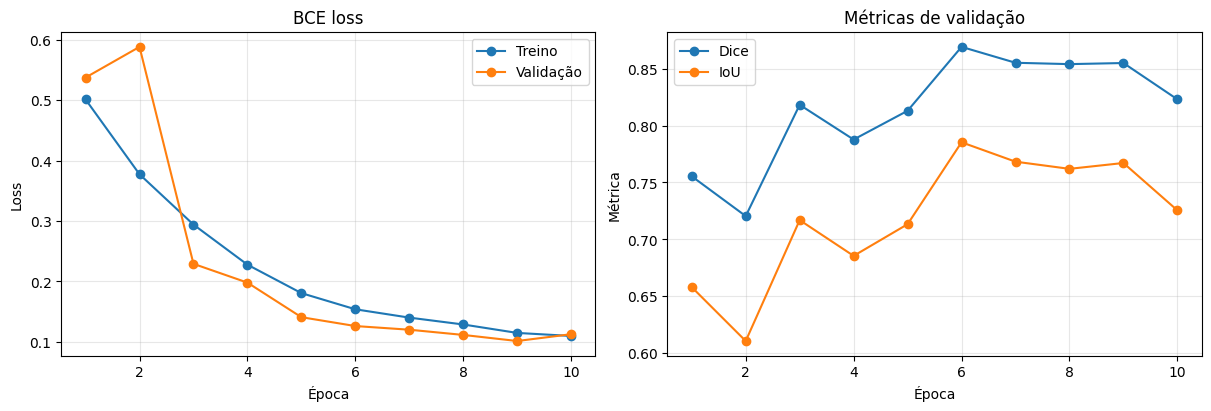

Menor val loss: época 9 (0.1014)
Maior val Dice: época 6 (0.8692)


In [31]:
real_history_frame = pd.DataFrame(real_training_history)

best_loss_row = real_history_frame.loc[real_history_frame["val_loss"].idxmin()]
best_dice_row = real_history_frame.loc[real_history_frame["val_dice"].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(
    real_history_frame["epoch"],
    real_history_frame["train_loss"],
    marker="o",
    label="Treino",
)
axes[0].plot(
    real_history_frame["epoch"],
    real_history_frame["val_loss"],
    marker="o",
    label="Validação",
)
axes[0].set_title("BCE loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    real_history_frame["epoch"],
    real_history_frame["val_dice"],
    marker="o",
    label="Dice",
)
axes[1].plot(
    real_history_frame["epoch"],
    real_history_frame["val_iou"],
    marker="o",
    label="IoU",
)
axes[1].set_title("Métricas de validação")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Métrica")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

print(
    f"Menor val loss: época {int(best_loss_row['epoch'])} "
    f"({best_loss_row['val_loss']:.4f})"
)
print(
    f"Maior val Dice: época {int(best_dice_row['epoch'])} "
    f"({best_dice_row['val_dice']:.4f})"
)

### Avaliação semântica no conjunto de teste

Depois de encerrar o treinamento e a seleção pela validação, avaliamos os pesos escolhidos nas 101 imagens de teste. O teste não participa de nenhuma atualização do modelo. Nesta etapa medimos apenas segmentação semântica; a avaliação por instância será adicionada após componentes conexos e matching.

In [32]:
real_test_metrics = evaluate_real_semantic(
    real_baseline_model,
    real_test_loader,
    real_baseline_criterion,
    device,
)

print("Baseline binária no teste")
print(f"Loss: {real_test_metrics['loss']:.4f}")
print(f"Dice: {real_test_metrics['dice']:.4f}")
print(f"IoU:  {real_test_metrics['iou']:.4f}")

Baseline binária no teste
Loss: 0.1094
Dice: 0.8552
IoU:  0.7685


### Da máscara binária para instâncias: componentes conexos

Aplicamos o limiar `0.5` às probabilidades e agrupamos pixels vizinhos. Usamos vizinhança 8: lados e diagonais contam como conexão. Cada grupo conectado recebe um ID inteiro. Esse método é a baseline de instâncias; quando dois núcleos encostam na máscara binária, eles recebem o mesmo ID e são contados como um único objeto.

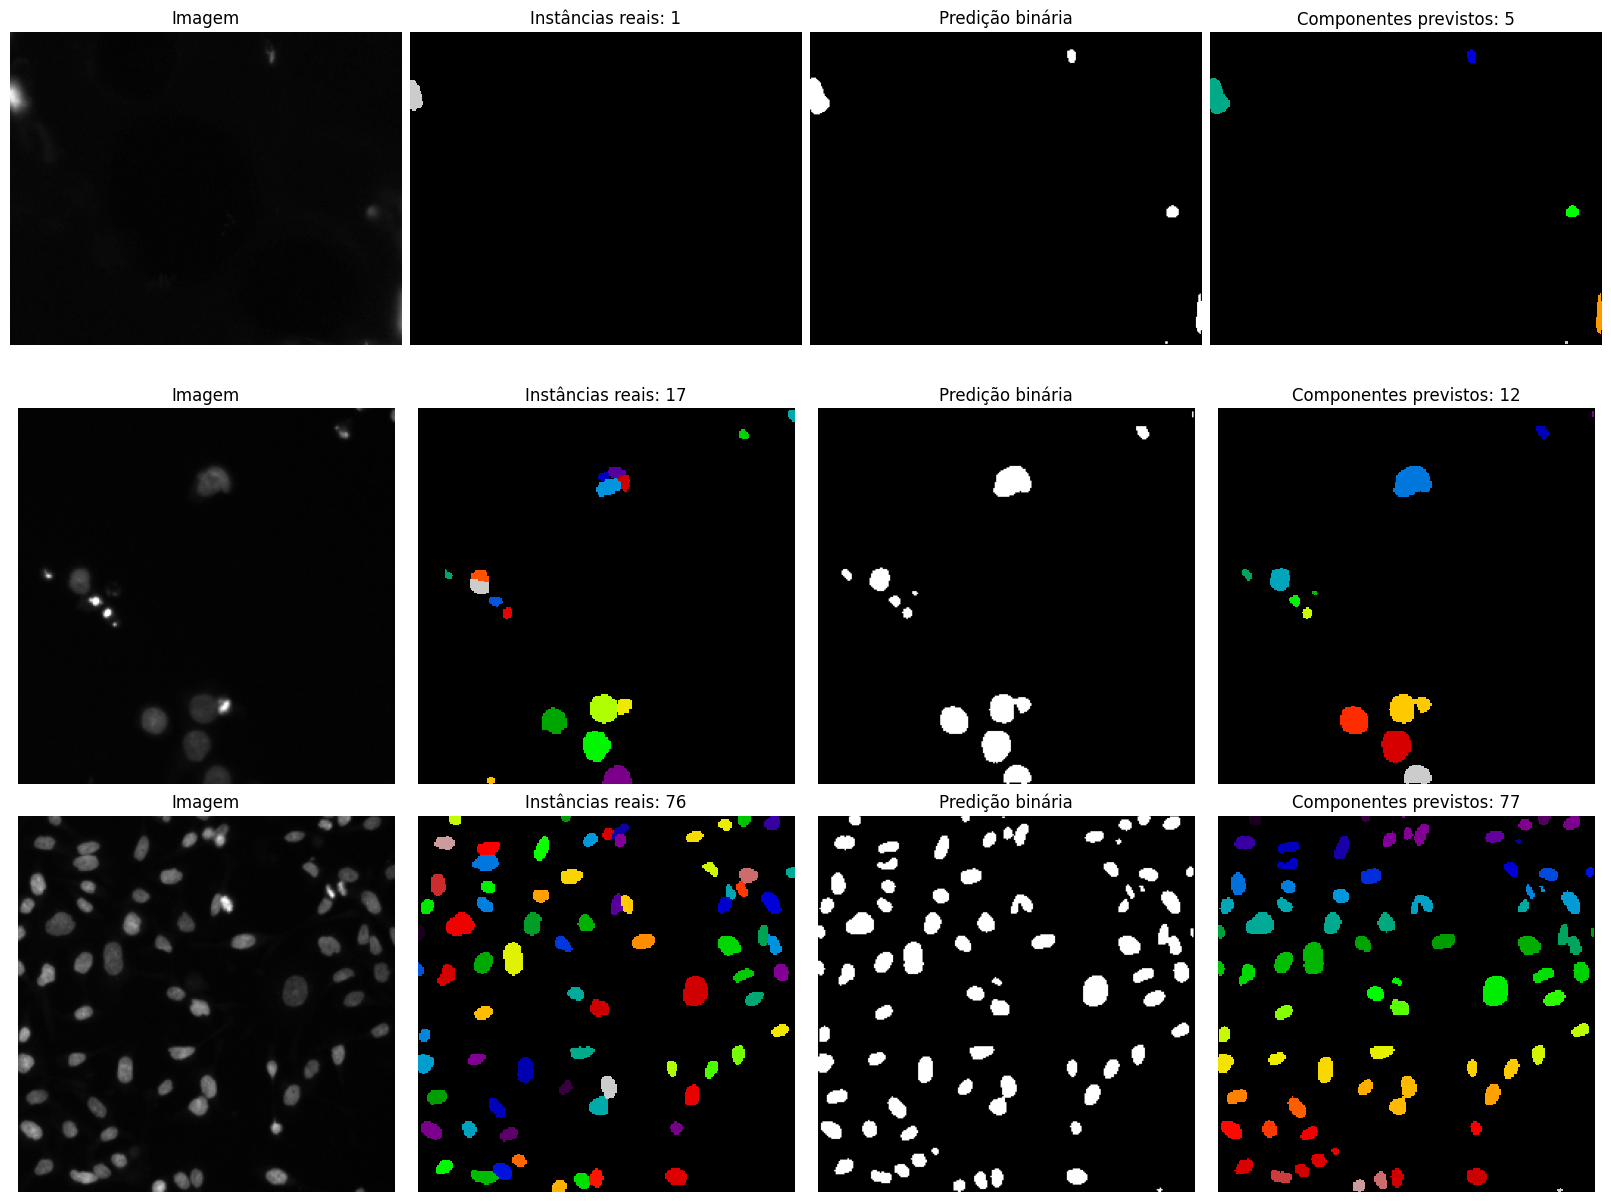

In [33]:
from scipy.ndimage import label


def binary_mask_to_instances(binary_mask):
    eight_neighbors = np.ones((3, 3), dtype=np.uint8)
    instance_mask, number_of_instances = label(
        binary_mask,
        structure=eight_neighbors,
    )
    return instance_mask.astype(np.int32), number_of_instances


# Escolhe exemplos nas extremidades e no meio da distribuição de densidade.
ordered_test_catalog = test_catalog.sort_values(
    "instances_per_100k_pixels"
)
selected_positions = [0, len(ordered_test_catalog) // 2, len(ordered_test_catalog) - 1]
selected_indices = ordered_test_catalog.index[selected_positions].tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 12), constrained_layout=True)
real_baseline_model.eval()

for row, dataset_index in enumerate(selected_indices):
    sample = real_test_dataset[dataset_index]
    image = sample["image"]
    true_instances = sample["instance_mask"].numpy()

    with torch.inference_mode():
        logits = forward_with_padding(
            real_baseline_model,
            image.unsqueeze(0).to(device),
        )
        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    predicted_binary = probability >= 0.5
    predicted_instances, predicted_count = binary_mask_to_instances(
        predicted_binary
    )
    true_count = int(true_instances.max())

    axes[row, 0].imshow(image[0], cmap="gray")
    axes[row, 0].set_title("Imagem")
    axes[row, 1].imshow(true_instances, cmap="nipy_spectral", interpolation="nearest")
    axes[row, 1].set_title(f"Instâncias reais: {true_count}")
    axes[row, 2].imshow(predicted_binary, cmap="gray")
    axes[row, 2].set_title("Predição binária")
    axes[row, 3].imshow(
        predicted_instances,
        cmap="nipy_spectral",
        interpolation="nearest",
    )
    axes[row, 3].set_title(f"Componentes previstos: {predicted_count}")

    for axis in axes[row]:
        axis.axis("off")

plt.show()

### Métricas por instância

Primeiro calculamos a IoU entre cada instância real e cada instância prevista. Para cada limiar de `0.50` a `0.95`, os pares são ordenados da maior para a menor IoU e cada objeto só pode ser associado uma vez. Objetos pareados são verdadeiros positivos (`TP`); previsões sem par são falsos positivos (`FP`); objetos reais sem par são falsos negativos (`FN`).

Em cada limiar calculamos `TP / (TP + FP + FN)`. O mAP da imagem é a média desses dez valores. Também calculamos `|quantidade prevista − quantidade real|`.

In [34]:
INSTANCE_IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)


def calculate_instance_iou_matrix(true_instances, predicted_instances):
    number_of_true_instances = int(true_instances.max())
    number_of_predicted_instances = int(predicted_instances.max())

    if number_of_true_instances == 0 or number_of_predicted_instances == 0:
        return np.zeros(
            (number_of_true_instances, number_of_predicted_instances),
            dtype=np.float32,
        )

    true_flat = true_instances.reshape(-1)
    predicted_flat = predicted_instances.reshape(-1)

    # Cada combinação (ID real, ID previsto) recebe um índice único.
    pair_indices = true_flat * (number_of_predicted_instances + 1)
    pair_indices = pair_indices + predicted_flat

    intersection_counts = np.bincount(
        pair_indices,
        minlength=(number_of_true_instances + 1)
        * (number_of_predicted_instances + 1),
    )
    intersection_counts = intersection_counts.reshape(
        number_of_true_instances + 1,
        number_of_predicted_instances + 1,
    )

    # A linha e a coluna zero representam o fundo e são removidas.
    intersections = intersection_counts[1:, 1:]
    true_areas = np.bincount(
        true_flat,
        minlength=number_of_true_instances + 1,
    )[1:]
    predicted_areas = np.bincount(
        predicted_flat,
        minlength=number_of_predicted_instances + 1,
    )[1:]

    unions = true_areas[:, None] + predicted_areas[None, :] - intersections
    return intersections / np.maximum(unions, 1)


def count_matches(iou_matrix, threshold):
    true_indices, predicted_indices = np.where(iou_matrix >= threshold)
    pair_scores = iou_matrix[true_indices, predicted_indices]
    order = np.argsort(pair_scores)[::-1]

    matched_true_instances = set()
    matched_predicted_instances = set()
    true_positives = 0

    for pair_index in order:
        true_index = int(true_indices[pair_index])
        predicted_index = int(predicted_indices[pair_index])

        true_already_matched = true_index in matched_true_instances
        prediction_already_matched = predicted_index in matched_predicted_instances

        if not true_already_matched and not prediction_already_matched:
            matched_true_instances.add(true_index)
            matched_predicted_instances.add(predicted_index)
            true_positives += 1

    return true_positives


def calculate_instance_metrics(true_instances, predicted_instances):
    number_of_true_instances = int(true_instances.max())
    number_of_predicted_instances = int(predicted_instances.max())
    iou_matrix = calculate_instance_iou_matrix(
        true_instances,
        predicted_instances,
    )

    scores_by_threshold = []

    for threshold in INSTANCE_IOU_THRESHOLDS:
        true_positives = count_matches(iou_matrix, threshold)
        false_positives = number_of_predicted_instances - true_positives
        false_negatives = number_of_true_instances - true_positives
        denominator = true_positives + false_positives + false_negatives

        if denominator == 0:
            score = 1.0
        else:
            score = true_positives / denominator

        scores_by_threshold.append(score)

    return {
        "map": float(np.mean(scores_by_threshold)),
        "count_error": abs(
            number_of_predicted_instances - number_of_true_instances
        ),
        "true_count": number_of_true_instances,
        "predicted_count": number_of_predicted_instances,
        "scores_by_threshold": scores_by_threshold,
    }


# Teste 1: uma previsão idêntica ao ground truth deve obter mAP 1.
small_ground_truth = np.array(
    [
        [0, 1, 1, 0],
        [0, 1, 1, 0],
        [0, 0, 2, 2],
        [0, 0, 2, 2],
    ],
    dtype=np.int32,
)
perfect_prediction = small_ground_truth.copy()
perfect_metrics = calculate_instance_metrics(
    small_ground_truth,
    perfect_prediction,
)
assert np.isclose(perfect_metrics["map"], 1.0)
assert perfect_metrics["count_error"] == 0

# Teste 2: unir os dois objetos em um só deve piorar o resultado.
merged_prediction = (small_ground_truth > 0).astype(np.int32)
merged_metrics = calculate_instance_metrics(
    small_ground_truth,
    merged_prediction,
)
assert merged_metrics["map"] < perfect_metrics["map"]
assert merged_metrics["count_error"] == 1

print("Previsão perfeita:", perfect_metrics)
print("Objetos unidos:", merged_metrics)
print("Testes das métricas concluídos sem erro.")

Previsão perfeita: {'map': 1.0, 'count_error': 0, 'true_count': 2, 'predicted_count': 2, 'scores_by_threshold': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}
Objetos unidos: {'map': 0.05, 'count_error': 1, 'true_count': 2, 'predicted_count': 1, 'scores_by_threshold': [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}
Testes das métricas concluídos sem erro.


### Avaliação de instâncias da baseline no teste

Para cada imagem de teste, convertemos os logits em probabilidades, aplicamos o limiar `0.5` e rotulamos os componentes conexos. Em seguida calculamos o mAP, o erro absoluto de contagem e o resultado em cada limiar de IoU. Mantemos uma linha por imagem para permitir análises posteriores por densidade.

In [35]:
baseline_instance_records = []
real_baseline_model.eval()

for dataset_index in range(len(real_test_dataset)):
    sample = real_test_dataset[dataset_index]
    image = sample["image"]
    true_instances = sample["instance_mask"].numpy()

    with torch.inference_mode():
        logits = forward_with_padding(
            real_baseline_model,
            image.unsqueeze(0).to(device),
        )
        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    predicted_binary = probability >= 0.5
    predicted_instances, _ = binary_mask_to_instances(predicted_binary)
    metrics = calculate_instance_metrics(
        true_instances,
        predicted_instances,
    )

    catalog_row = test_catalog.iloc[dataset_index]
    record = {
        "image_id": sample["image_id"],
        "density": catalog_row["instances_per_100k_pixels"],
        "density_bin": catalog_row["density_bin"],
        "map": metrics["map"],
        "count_error": metrics["count_error"],
        "count_bias": metrics["predicted_count"] - metrics["true_count"],
        "true_count": metrics["true_count"],
        "predicted_count": metrics["predicted_count"],
    }

    for threshold, score in zip(
        INSTANCE_IOU_THRESHOLDS,
        metrics["scores_by_threshold"],
    ):
        column_name = f"score_iou_{threshold:.2f}"
        record[column_name] = score

    baseline_instance_records.append(record)

    number_processed = dataset_index + 1
    if number_processed % 20 == 0 or number_processed == len(real_test_dataset):
        print(f"Processadas {number_processed}/{len(real_test_dataset)} imagens")

baseline_instance_results = pd.DataFrame(baseline_instance_records)
assert len(baseline_instance_results) == len(real_test_dataset)

baseline_map = baseline_instance_results["map"].mean()
baseline_count_mae = baseline_instance_results["count_error"].mean()
baseline_count_bias = baseline_instance_results["count_bias"].mean()

print()
print("Baseline de instâncias no teste")
print(f"mAP (IoU 0.50:0.95): {baseline_map:.4f}")
print(f"Erro absoluto médio de contagem: {baseline_count_mae:.2f}")
print(f"Viés médio de contagem: {baseline_count_bias:+.2f}")

threshold_columns = [
    f"score_iou_{threshold:.2f}" for threshold in INSTANCE_IOU_THRESHOLDS
]
mean_score_by_threshold = baseline_instance_results[threshold_columns].mean()
display(mean_score_by_threshold.rename("score médio").to_frame())

Processadas 20/101 imagens
Processadas 40/101 imagens
Processadas 60/101 imagens
Processadas 80/101 imagens
Processadas 100/101 imagens
Processadas 101/101 imagens

Baseline de instâncias no teste
mAP (IoU 0.50:0.95): 0.4103
Erro absoluto médio de contagem: 9.50
Viés médio de contagem: -8.28


,score médio
score_iou_0.50,0.618865
score_iou_0.55,0.586603
score_iou_0.60,0.554161
score_iou_0.65,0.519820
score_iou_0.70,0.473006
score_iou_0.75,0.438412
score_iou_0.80,0.384095
score_iou_0.85,0.311462
score_iou_0.90,0.177518
score_iou_0.95,0.038875


### Falha da baseline em função da densidade

Agrupamos as imagens nas mesmas cinco faixas de densidade usadas no split. Em cada faixa mostramos o mAP médio e o erro absoluto médio de contagem. Essa análise verifica se a baseline se degrada quando há mais núcleos próximos e, portanto, mais oportunidades de fusão.

,number_of_images,mean_map,mean_count_error,mean_count_bias
density_bin,,,,
muito baixa,21,0.447,3.00,2.238
baixa,20,0.567,2.85,-2.850
média,20,0.376,4.65,-4.350
alta,20,0.382,8.70,-8.600
muito alta,20,0.277,28.65,-28.350


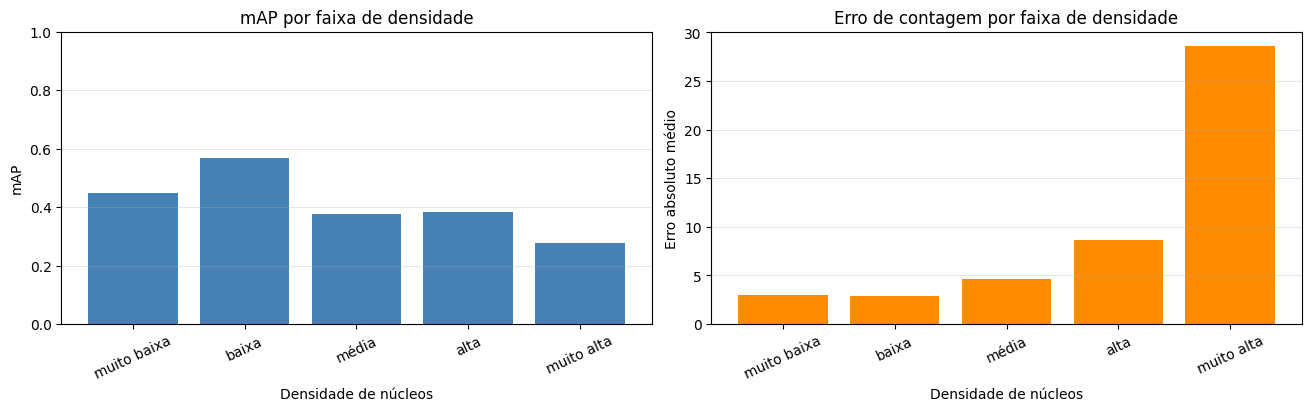

In [36]:
density_failure_summary = (
    baseline_instance_results.groupby("density_bin", observed=True)
    .agg(
        number_of_images=("image_id", "count"),
        mean_map=("map", "mean"),
        mean_count_error=("count_error", "mean"),
        mean_count_bias=("count_bias", "mean"),
    )
    .reindex(density_labels)
)

display(density_failure_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].bar(
    density_failure_summary.index,
    density_failure_summary["mean_map"],
    color="steelblue",
)
axes[0].set_title("mAP por faixa de densidade")
axes[0].set_xlabel("Densidade de núcleos")
axes[0].set_ylabel("mAP")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    density_failure_summary.index,
    density_failure_summary["mean_count_error"],
    color="darkorange",
)
axes[1].set_title("Erro de contagem por faixa de densidade")
axes[1].set_xlabel("Densidade de núcleos")
axes[1].set_ylabel("Erro absoluto médio")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.show()

## Parte 2 — Cabeça de instâncias com fronteiras e watershed

A baseline reconhece bem o conjunto de pixels pertencentes a núcleos, mas componentes conexos não conseguem separar objetos que se tocam. Na trilha escolhida, a rede aprende duas tarefas: prever foreground e prever as bordas internas dos núcleos. As regiões internas separadas servirão como marcadores para o watershed.

### Construção do alvo de fronteiras

Para cada instância, removemos uma camada de pixels da sua borda por erosão. A diferença entre a máscara original e a versão erodida é a fronteira. O cálculo é feito separadamente para cada ID, preservando inclusive a divisão entre objetos encostados.

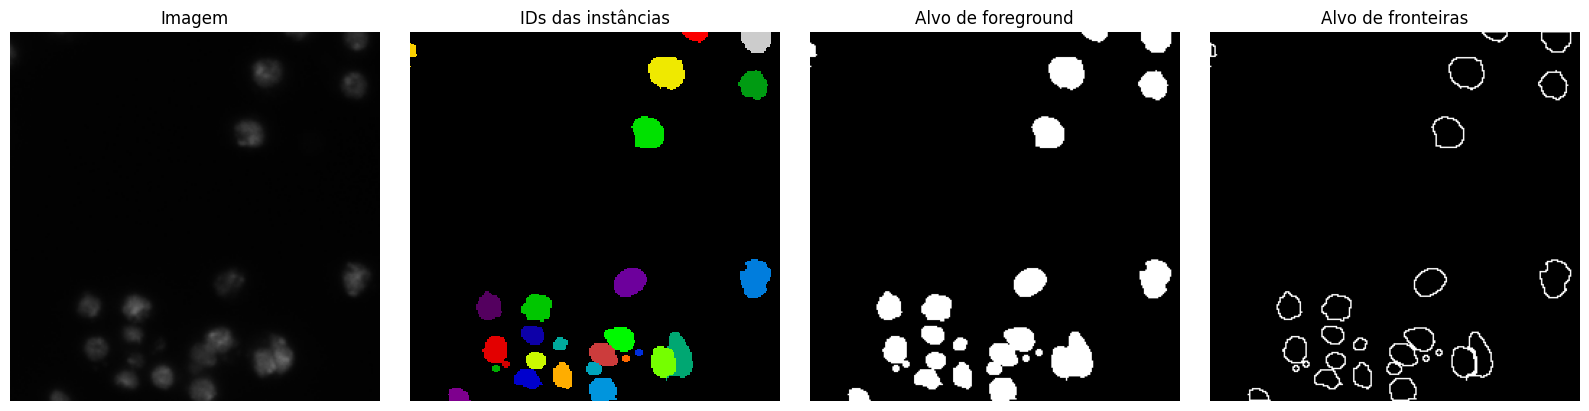

Pixels de foreground: 5715
Pixels de fronteira: 1583


In [37]:
from scipy.ndimage import binary_erosion


def create_boundary_target(instance_mask):
    boundary_mask = np.zeros(instance_mask.shape, dtype=bool)
    neighborhood = np.ones((3, 3), dtype=bool)
    number_of_instances = int(instance_mask.max())

    for instance_id in range(1, number_of_instances + 1):
        object_mask = instance_mask == instance_id
        eroded_object = binary_erosion(
            object_mask,
            structure=neighborhood,
            border_value=0,
        )
        object_boundary = object_mask & ~eroded_object
        boundary_mask |= object_boundary

    return boundary_mask


example_boundary = create_boundary_target(real_instance_mask)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
axes[0].imshow(real_image)
axes[0].set_title("Imagem")
axes[1].imshow(real_instance_mask, cmap="nipy_spectral", interpolation="nearest")
axes[1].set_title("IDs das instâncias")
axes[2].imshow(real_binary_mask, cmap="gray")
axes[2].set_title("Alvo de foreground")
axes[3].imshow(example_boundary, cmap="gray")
axes[3].set_title("Alvo de fronteiras")

for axis in axes:
    axis.axis("off")

plt.show()

assert example_boundary.shape == real_binary_mask.shape
assert np.all(example_boundary <= real_binary_mask)
print("Pixels de foreground:", int(real_binary_mask.sum()))
print("Pixels de fronteira:", int(example_boundary.sum()))